In [1]:
import numpy as np
import scipy.stats as stats
from tqdm import tqdm
from scipy.stats import invwishart
from scipy.stats import wishart
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
global bounds, d
d = 2
bound = 10
bounds = (-bound, bound)

In [3]:
def prior():
    
    global bounds, d
    lb, ub = bounds
    
    #> drawing mean vector and standard deviations
    
    # sample std deviations
    mu = np.random.uniform(lb,ub,size=d)
    sigma = np.random.uniform((ub-lb)/1e3,(ub-lb)/1e1,size=d)
    
    #> random wishart covariance?
    # https://www.math.wustl.edu/~sawyer/hmhandouts/Wishart.pdf
    #A = np.random.normal(size=(d,d))
    #S = A @ A.T

    S = invwishart.rvs(df=d+1, scale=np.identity(d))
    # S = wishart.rvs(df=d, scale=np.identity(d))

    #> convert to correlation matrix
    Dcorr = np.sqrt(np.diag(S)) # .reshape(d,1) # needed if wanting to use Dcorr @ Dcorr.T
    R = S / np.outer(Dcorr, Dcorr) # why not Dcorr @ Dcorr.T? (it is the same!)
    
    #> getting lower triangle values
    idx = np.tril_indices(d, k=-1)
    r = R[idx]
    
    # cov = np.diag(sigma) @ R @ np.diag(sigma)
    
    return np.hstack([mu, sigma, r])

In [4]:
#> declarations
num_samples = 10000
samples = []

for i in tqdm(range(num_samples)):
    samples.append(prior())
samples = np.array(samples)

100%|██████████| 10000/10000 [00:05<00:00, 1769.76it/s]


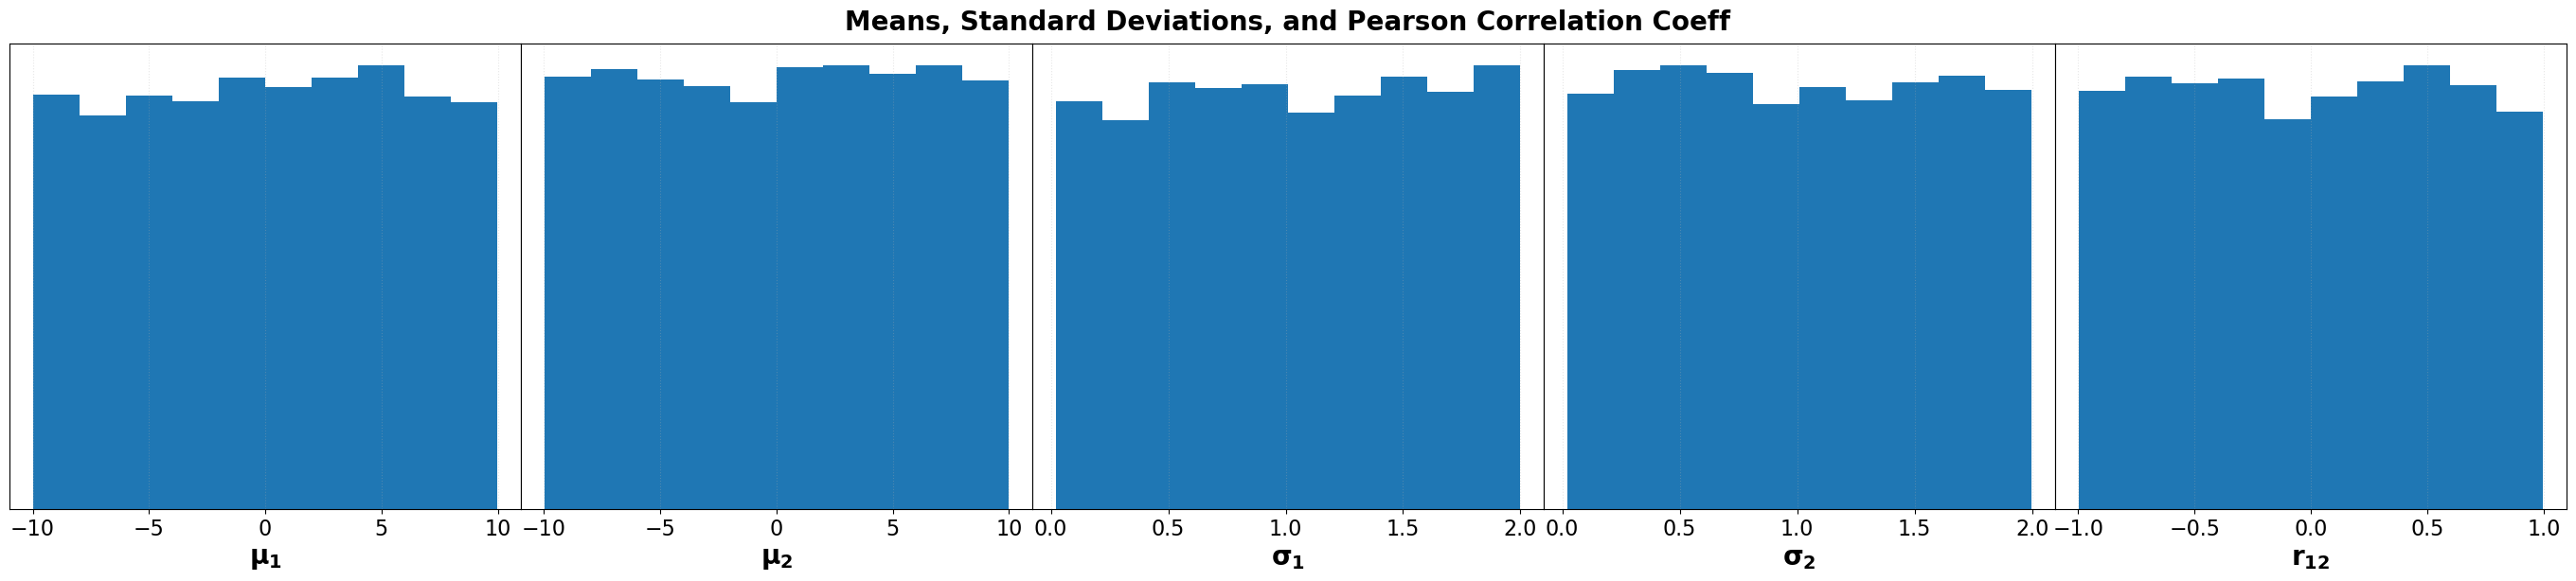

In [5]:
#> initializing plot
fig, axes = plt.subplots(1,5,figsize=(6*5, 6))
labels = [r'$\mathbf{\mu_1}$', r'$\mathbf{\mu_2}$', 
          r'$\mathbf{\sigma_1}$', r'$\mathbf{\sigma_2}$', 
          r'$\mathbf{r_{12}}$']

#> fig title
plt.suptitle('Means, Standard Deviations, and Pearson Correlation Coeff', fontweight='bold', fontsize=20)
plt.subplots_adjust(left=0.05, bottom=0.1, right=0.95, top=0.92, wspace=0.0, hspace=0.0)

#> plotting!
for i, ax in enumerate(axes.flat):
    ax.set_yticks([])
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax.tick_params(axis='x', which='major', labelsize=16)
    ax.grid(ls=':', alpha=0.3)
    ax.hist(samples[:,i])
    ax.set_xlabel(labels[i], fontweight='bold', fontsize=20)

plt.show()

In [6]:
#> unpacking
mus = samples[:,:d]
sigmas = samples[:,d:2*d]
rs = samples[:,-1]

#> creating covariance matrix
samples_cov = []
for mu, sigma, r in zip(mus, sigmas, rs):

    #> creating covariance matrix
    R = np.identity(len(mu))
    idx = np.tril_indices(len(mu), k=-1)
    R[idx] = r; R.T[idx] = r
    
    #> creating covariance
    cov = np.diag(sigma) @ R @ np.diag(sigma)

    #> saving
    samples_cov.append(np.hstack([mu, cov[0][0], cov[1][1], cov[0][1]]))
samples_cov = np.array(samples_cov)

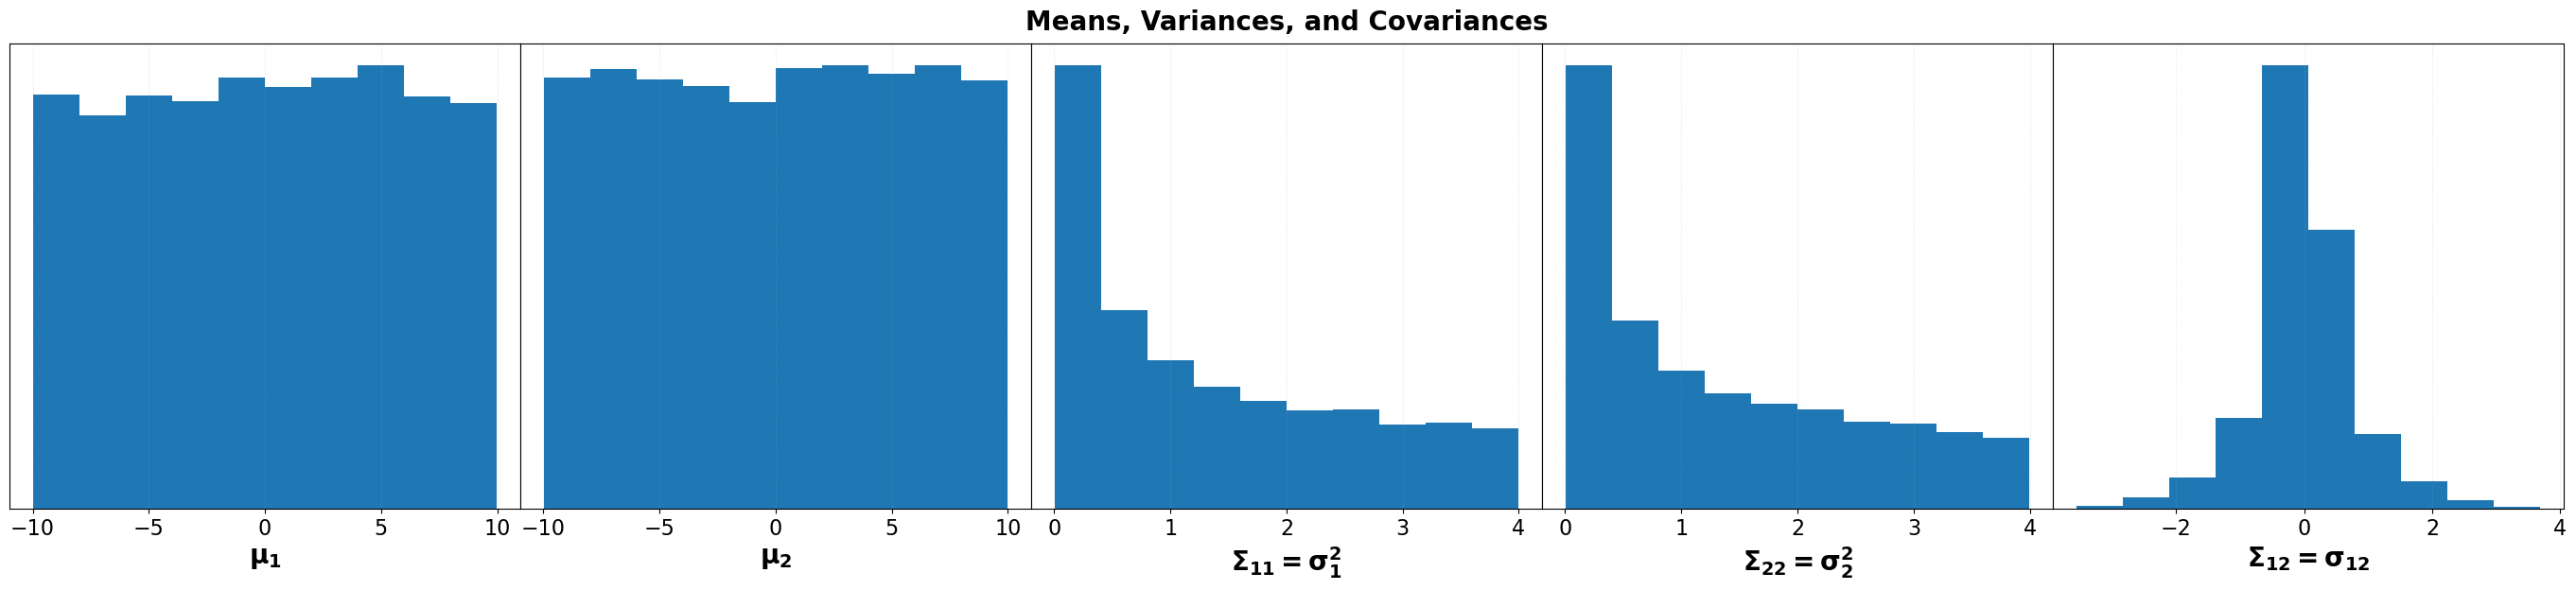

In [7]:
#> initializing plot
fig, axes = plt.subplots(1,5,figsize=(6*5, 6))
labels = [r'$\mathbf{\mu_1}$', r'$\mathbf{\mu_2}$', 
          r'$\mathbf{\Sigma_{11}=\sigma^2_1}$', r'$\mathbf{\Sigma_{22}=\sigma^2_2}$', 
          r'$\mathbf{\Sigma_{12}=\sigma_{12}}$']

#> fig title
plt.suptitle('Means, Variances, and Covariances', fontweight='bold', fontsize=20)
plt.subplots_adjust(left=0.05, bottom=0.1, right=0.95, top=0.92, wspace=0.0, hspace=0.0)

#> plotting!
for i, ax in enumerate(axes.flat):
    
    ax.set_yticks([])
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax.tick_params(axis='x', which='major', labelsize=16)
    ax.grid(ls=':', alpha=0.3)
    ax.hist(samples_cov[:,i])
    ax.set_xlabel(labels[i], fontweight='bold', fontsize=20)

plt.show()

In [8]:
#> reconstructing correlations and standard deviations
reconstructed_sample = []
for sample in tqdm(samples_cov):

    #> unpacking
    var1 = sample[2]
    var2 = sample[3]
    covar = sample[4]

    #> standard deviation
    std1 = np.sqrt(var1)
    std2 = np.sqrt(var2)

    #> pearson coeff
    r12 = covar / (std1 * std2)

    reconstructed_sample.append([sample[0], sample[1], std1, std2, r12])
reconstructed_sample = np.array(reconstructed_sample)

100%|██████████| 10000/10000 [00:00<00:00, 77905.00it/s]


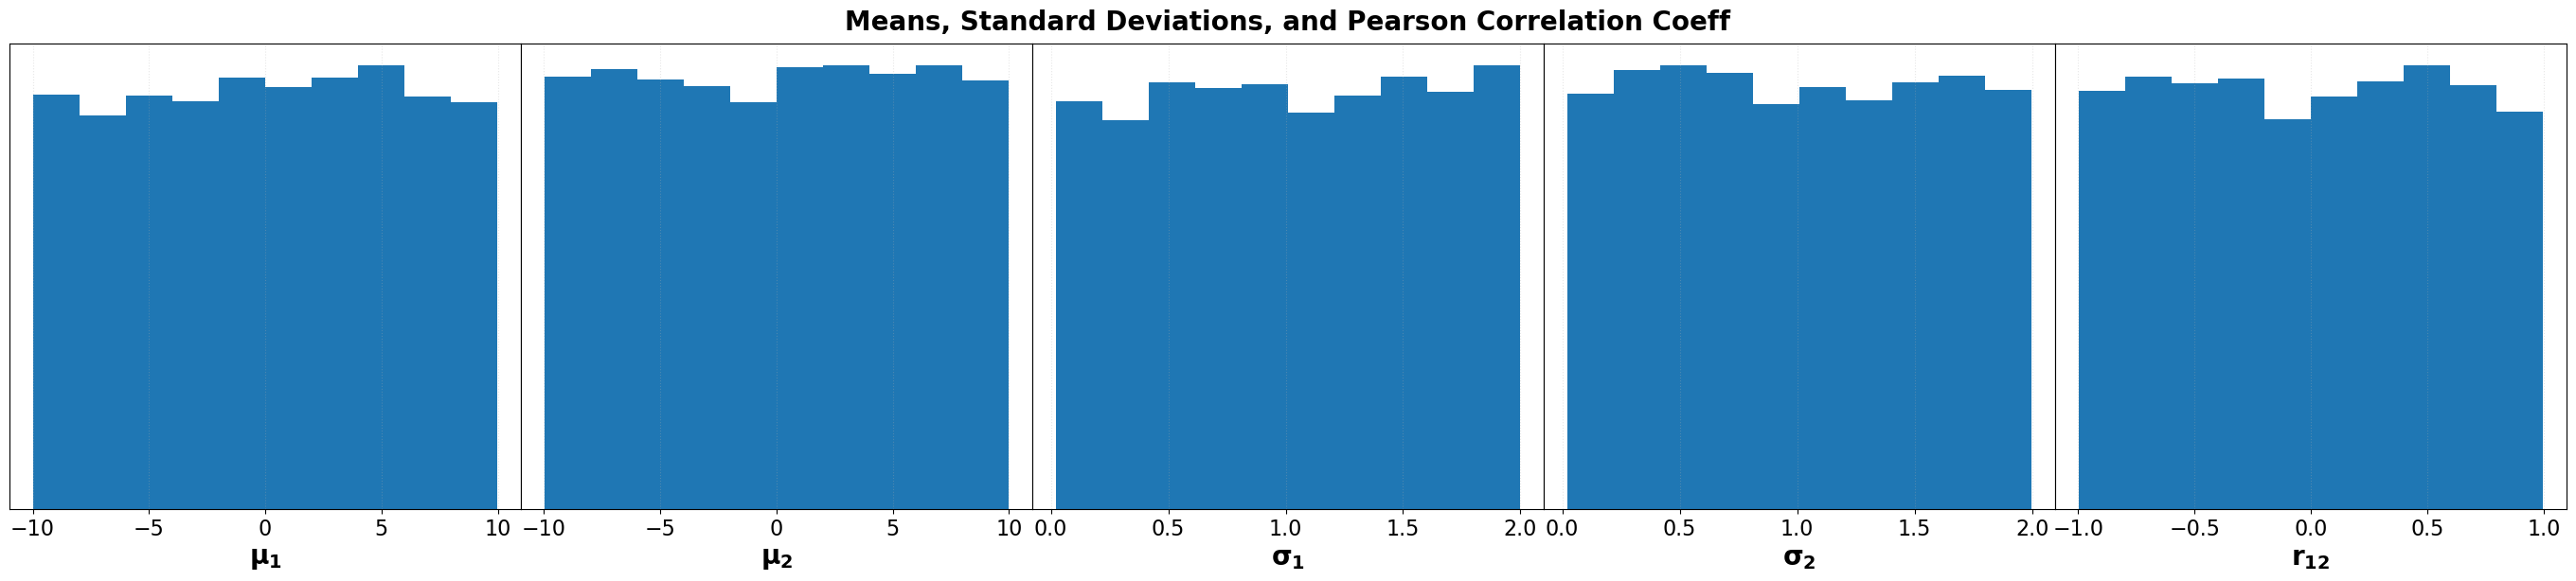

In [9]:
#> initializing plot
fig, axes = plt.subplots(1,5,figsize=(6*5, 6))
labels = [r'$\mathbf{\mu_1}$', r'$\mathbf{\mu_2}$', 
          r'$\mathbf{\sigma_1}$', r'$\mathbf{\sigma_2}$', 
          r'$\mathbf{r_{12}}$']

#> fig title
plt.suptitle('Means, Standard Deviations, and Pearson Correlation Coeff', fontweight='bold', fontsize=20)
plt.subplots_adjust(left=0.05, bottom=0.1, right=0.95, top=0.92, wspace=0.0, hspace=0.0)

#> plotting!
for i, ax in enumerate(axes.flat):
    ax.set_yticks([])
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax.tick_params(axis='x', which='major', labelsize=16)
    ax.grid(ls=':', alpha=0.3)
    ax.hist(reconstructed_sample[:,i])
    ax.set_xlabel(labels[i], fontweight='bold', fontsize=20)

plt.show()

### **Larger Dimensions**

In [10]:
global bounds, d
d = 3
bound = 10
bounds = (-bound, bound)

In [11]:
#> declarations
num_samples = 10000
samples = []
num_r = int(d*(d+1)/2 - d)

for i in tqdm(range(num_samples)):
    samples.append(prior())
samples = np.array(samples)
r_samples = samples[:,-num_r:]
print(r_samples)
print(len(r_samples[0]))

100%|██████████| 10000/10000 [00:05<00:00, 1699.21it/s]

[[-0.77632163 -0.51719832  0.82235521]
 [ 0.7872055   0.79447281  0.92366697]
 [-0.08312738  0.61545681  0.35542468]
 ...
 [ 0.29004845 -0.61711584  0.28092079]
 [-0.11645472 -0.57048139 -0.46927199]
 [-0.94767043  0.99385482 -0.96777127]]
3


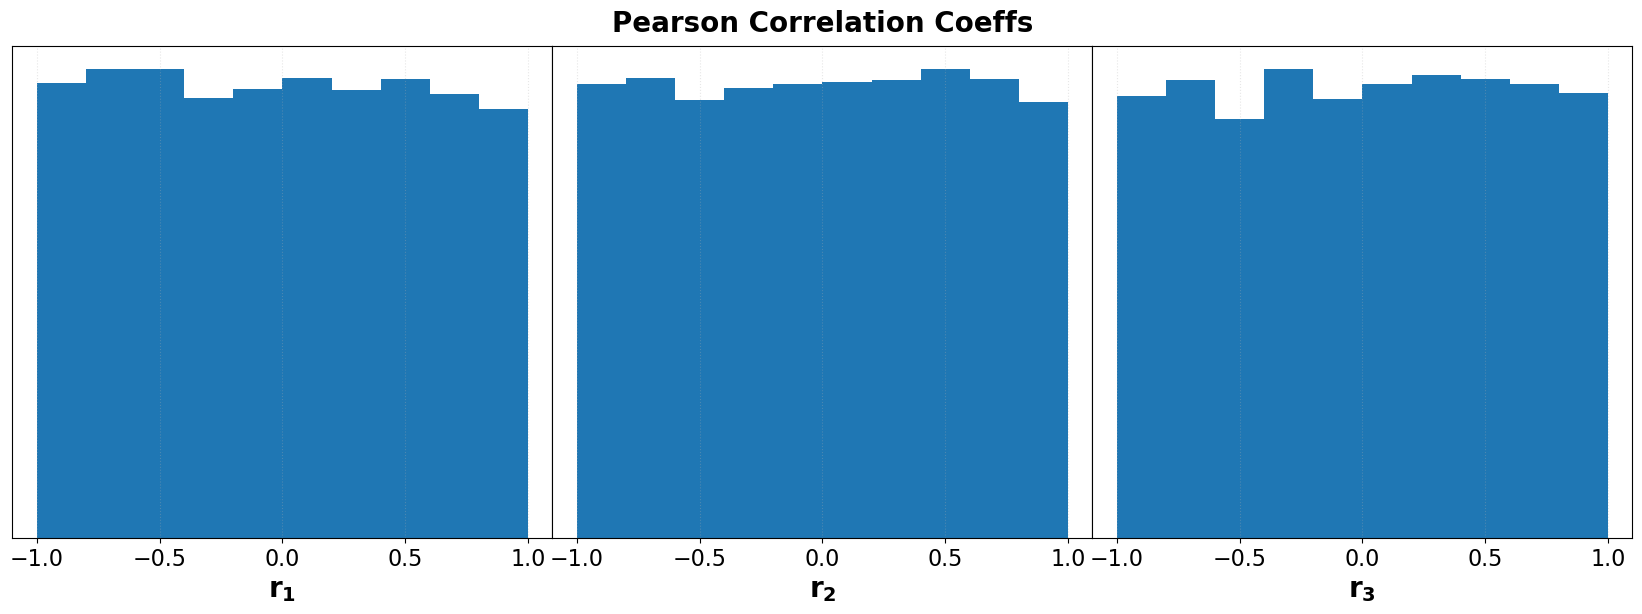

In [12]:
#> initializing plot
fig, axes = plt.subplots(1,num_r,figsize=(6*num_r, 6))

#> fig title
plt.suptitle('Pearson Correlation Coeffs', fontweight='bold', fontsize=20)
plt.subplots_adjust(left=0.05, bottom=0.1, right=0.95, top=0.92, wspace=0.0, hspace=0.0)

#> plotting!
for i, ax in enumerate(axes.flat):
    ax.set_yticks([])
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax.tick_params(axis='x', which='major', labelsize=16)
    ax.grid(ls=':', alpha=0.3)
    ax.hist(r_samples[:,i])
    ax.set_xlabel(r'$\mathbf{r_{%i}}$' % (i+1), fontweight='bold', fontsize=20)

plt.show()

0 0 0
1 0 1
2 0 2
3 1 0
4 1 1
5 1 2
6 2 0
7 2 1
8 2 2


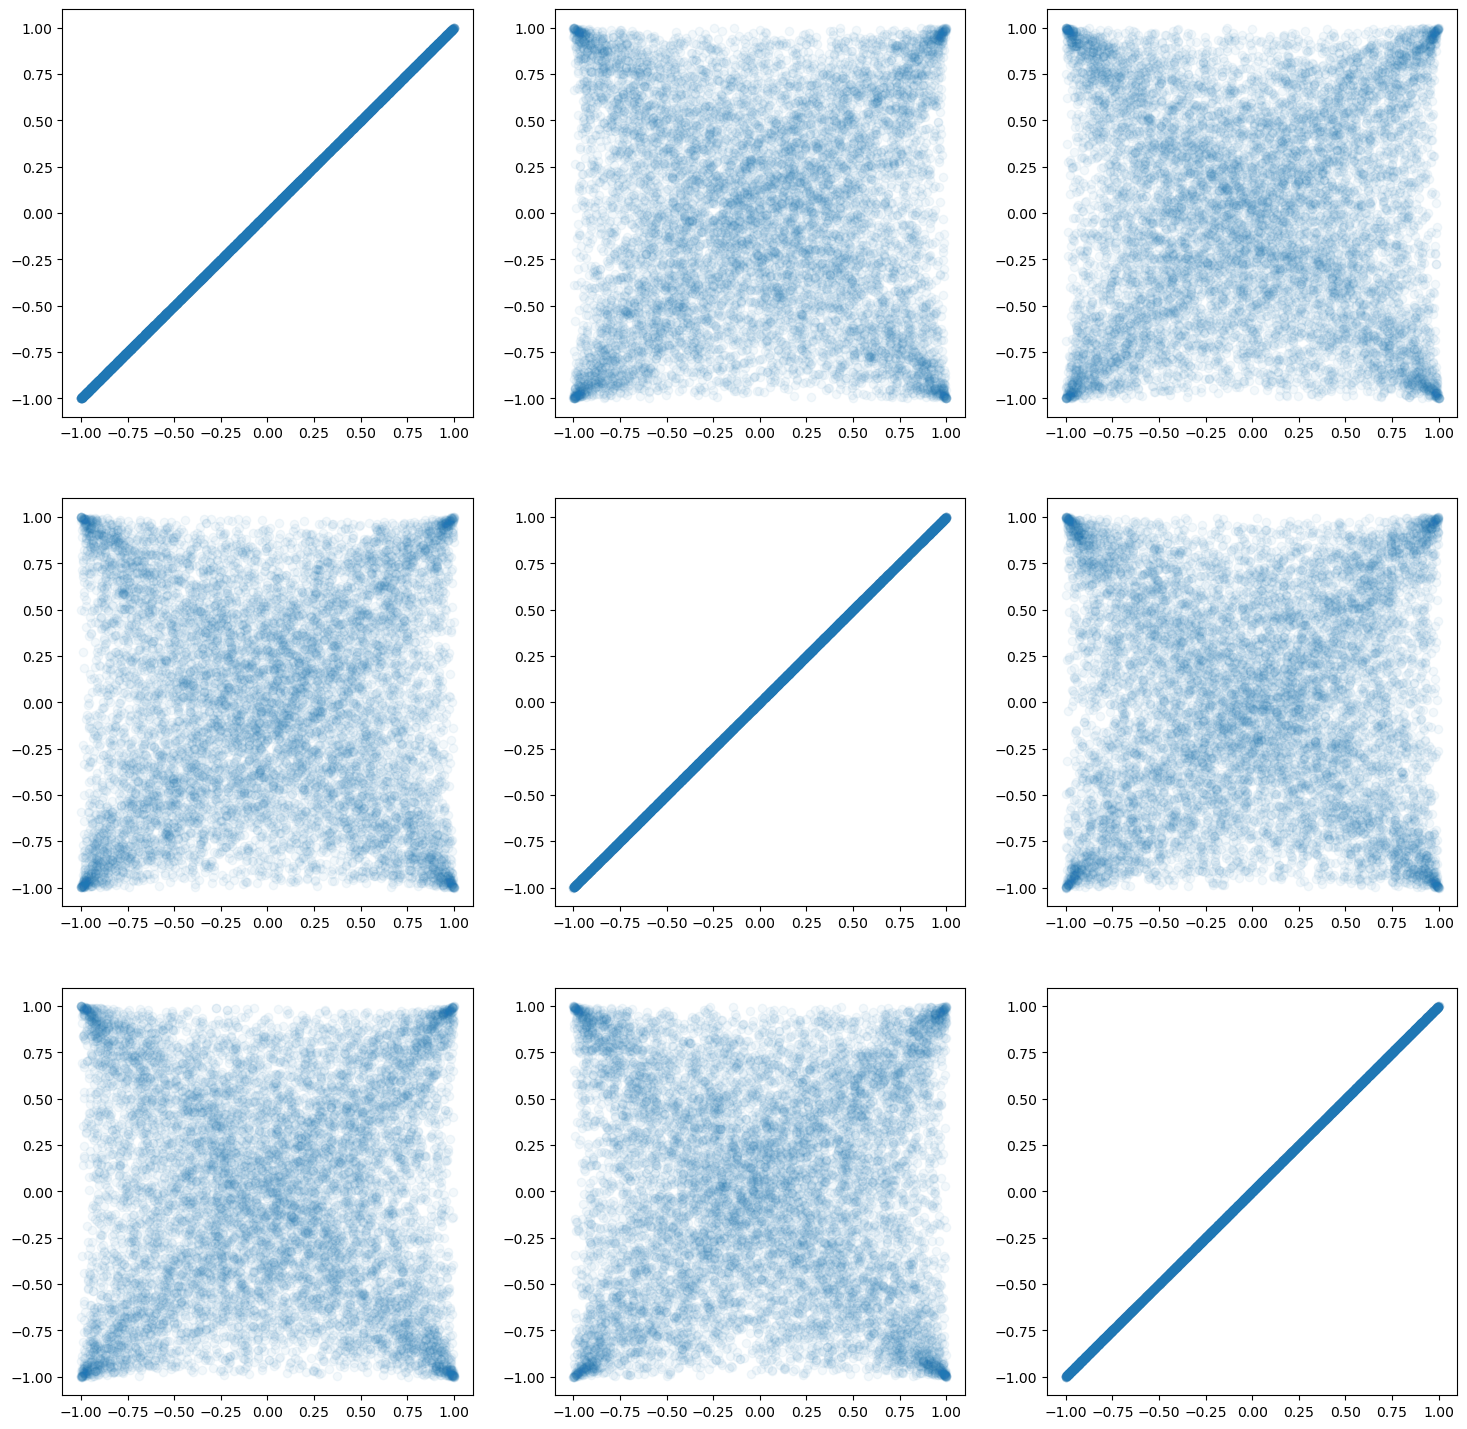

In [13]:
fig, axes = plt.subplots(num_r,num_r,figsize=(6*num_r, 6*num_r))

for i, ax in enumerate(axes.flat):

    row = int(i/3)
    column = i % 3
    print(i, row, column)
    ax.scatter(r_samples[:,row], r_samples[:,column], alpha=0.05)

plt.show()

In [14]:
uniform_sample = []
for i in tqdm(range(num_samples)):
    uniform_sample.append(np.random.uniform(size=2))
uniform_sample = np.array(uniform_sample)

100%|██████████| 10000/10000 [00:00<00:00, 79522.22it/s]


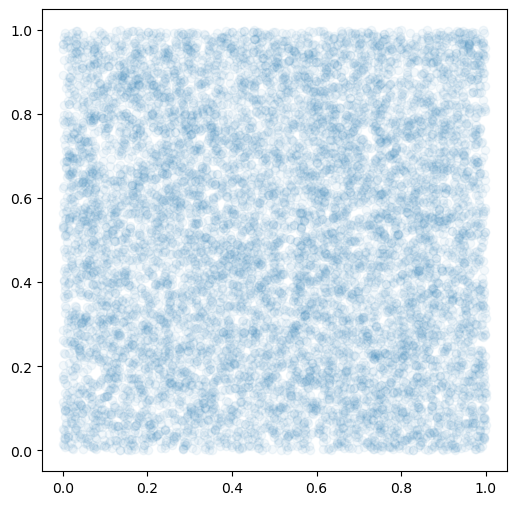

In [15]:
fig, ax = plt.subplots(1,1,figsize=(6,6))
ax.scatter(uniform_sample[:,0], uniform_sample[:,1], alpha=0.05)
plt.show()